# Comprehensive Analysis of Electronic Store eCommerce Purchase History

### Table of Contents
1. Data & Setup

2. Data Cleaning & Transformation

3. Product & Category Analysis

4. Time and Purchase Frequency Analysis

5. Basket Analysis

6. Customer Analysis

7. Brand Analysis

8. Risks and Limitations

9. Final Summary

## 1. Data & Setup

Originally sourced from the Open Customer Data Platform (CDP) project and curated by Michael Kechinov, this dataset spans over an eight-month operational window spanning from April 2020 to November 2020. Each row in the file represents an event. All events are related to products and users. Each event is like many-to-many relation between products and users.

| Column Name   | Type       | Description                                             |
| ------------- | ---------- | ------------------------------------------------------- |
| event_time    | datetime   | Timestamp of when the event occurred.                   |
| order_id      | string     | Unique identifier for each order.                       |
| product_id    | string     | Unique identifier for each product.                     |
| category_id   | string     | Unique identifier for the product category.             |
| category_code | string     | Readable category and sub-category name (if available). |
| brand         | string     | Brand name (in lowercase, if available).                |
| price         | float      | Product price at purchase time.                         |
| user_id       | string     | Unique identifier for the user.                         |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DARK_BG   = "#eaeaea"
PANEL_BG  = '#f0f0f0'
ACCENT    = '#e94560'
BLUE      = '#0f3460'
TEAL      = '#00b4d8'
GOLD      = '#ffd166'
GREEN     = '#06d6a0'
PURPLE    = '#845ec2'
TEXT      = '#1a1a2e'
SUBTEXT   = '#1a1a2e'

PALETTE   = [ACCENT, TEAL, GOLD, GREEN, PURPLE, '#ff9f1c', '#2ec4b6', '#e76f51']

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : PANEL_BG,
    'axes.edgecolor'   : '#2a2a4a',
    'axes.labelcolor'  : TEXT,
    'xtick.color'      : SUBTEXT,
    'ytick.color'      : SUBTEXT,
    'text.color'       : TEXT,
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

In [3]:
df_raw = pd.read_csv('kz.csv', low_memory=False)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape: (2633521, 8)
Columns: ['event_time', 'order_id', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id']


,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18


In [4]:
print('Data Types ')
print(df_raw.dtypes)
print('\nMissing Values ')
print(df_raw.isnull().sum())
print(f'\nTotal rows: {len(df_raw):,} ')

Data Types 
event_time        object
order_id           int64
product_id         int64
category_id      float64
category_code     object
brand             object
price            float64
user_id          float64
dtype: object

Missing Values 
event_time             0
order_id               0
product_id             0
category_id       431954
category_code     612202
brand             506005
price             431954
user_id          2069352
dtype: int64

Total rows: 2,633,521 


---
## 2. Data Cleaning & Transformation


In [5]:
df = df_raw.copy()

# ── STEP 1: Date & Time Cleaning ─────────────────────────────────────────────
df['event_time'] = df['event_time'].astype(str).str.replace(' UTC', '', regex=False).str.strip()
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

df = df[df['event_time'].dt.year > 2000].copy()

df['event_time_date'] = df['event_time'].dt.date
df['Day_Name']        = df['event_time'].dt.day_name()
df['Day_Number']      = df['event_time'].dt.dayofweek   # Monday=0
df['Hour_Rounded']    = df['event_time'].dt.hour
df['Month']           = df['event_time'].dt.month
df['Month_Name']      = df['event_time'].dt.strftime('%b')


# ── STEP 2: Price Cleaning ────────────────────────────────────────────────────
df['price'] = (
    df['price'].astype(str)
      .str.replace(',', '.', regex=False)
      .str.strip()
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# ── STEP 3: Category & Product Transformation ─────────────────────────────────
df = df.rename(columns={'product_id': 'product_model_id', 'brand': 'brand_name'})

cat_split = df['category_code'].astype(str).str.split('.', expand=True)
df['category_name']     = cat_split[0] if 0 in cat_split.columns else np.nan
df['sub_category_name'] = cat_split[1] if 1 in cat_split.columns else np.nan
df['product_name']      = cat_split[2] if 2 in cat_split.columns else np.nan


# ── STEP 4: Handle Missing / Non-Standard Values ──────────────────────────────
CRITICAL_COLS     = ['event_time', 'order_id', 'product_model_id', 'category_id', 'price']
NON_CRITICAL_COLS = ['category_name', 'sub_category_name', 'product_name', 'brand_name', 'user_id']

critical_missing  = df[CRITICAL_COLS].isnull().any(axis=1)
non_crit_missing  = (~critical_missing) & df[NON_CRITICAL_COLS].isnull().any(axis=1)
fully_complete    = (~critical_missing) & (~non_crit_missing)

df['Flag_data'] = np.where(critical_missing,  'Critical Missing Data',
                  np.where(non_crit_missing,   'Non-Critical Missing Data',
                                               'Fully Complete'))

for col in NON_CRITICAL_COLS + ['category_name', 'sub_category_name', 'product_name']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').replace({'none': 'Unknown', 'nan': 'Unknown'})
        df[col] = df[col].astype(str).str.strip().str.lower()

if 'brand_name' in df.columns:
    df['brand_name'] = df['brand_name'].fillna('Unknown').astype(str).str.strip().str.lower()

print(df['Flag_data'].value_counts())

# ── STEP 5: Filter – Remove Critical Missing ──────────────────────────────────
df_clean = df[df['Flag_data'] != 'Critical Missing Data'].copy()
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())
print(f'\nRows after removing critical missing: {len(df_clean):,}')

Flag_data
Non-Critical Missing Data    1940527
Critical Missing Data         427876
Fully Complete                245487
Name: count, dtype: int64

Rows after removing critical missing: 2,186,014


In [6]:
# ── STEP 6: Customer-Level Derived Columns ────────────────────────────────────
df_u = df_clean[df_clean['user_id'].notna() & (df_clean['user_id'].astype(str) != 'nan')].copy()
df_u['user_id'] = df_u['user_id'].astype(str)

user_orders = (
    df_u.groupby('user_id')['order_id']
        .nunique()
        .reset_index(name='order_count')
)

def customer_cat(n):
    if n == 1: return 'Occasional'
    if n == 2: return 'Recurrent'
    return 'Loyal'

user_orders['Customer_Category'] = user_orders['order_count'].apply(customer_cat)

def avg_days_between(g):
    dates = g['event_time'].dt.normalize().drop_duplicates().sort_values()
    if len(dates) < 2: return np.nan
    return dates.diff().dropna().dt.days.mean()

avg_days = df_u.groupby('user_id').apply(avg_days_between).reset_index()
avg_days.columns = ['user_id', 'Avg_days_between_orders']

# Basket size (avg price per order per user)
order_value = (
    df_u.groupby(['user_id', 'order_id'])['price']
        .sum()
        .reset_index(name='order_value')
)
user_basket = order_value.groupby('user_id')['order_value'].mean().reset_index(name='avg_basket')

def basket_seg(v):
    if v < 100:  return 'Small'
    if v < 400:  return 'Average'
    return 'Large'

user_basket['BasketSegment'] = user_basket['avg_basket'].apply(basket_seg)

# Favorite category
fav_cat = (
    df_u[df_u['category_name'] != 'unknown']
      .groupby(['user_id', 'category_name'])
      .size()
      .reset_index(name='cnt')
      .sort_values('cnt', ascending=False)
      .drop_duplicates('user_id')[['user_id', 'category_name']]
      .rename(columns={'category_name': 'favorite_category'})
)

user_enriched = (
    user_orders
      .merge(avg_days,    on='user_id', how='left')
      .merge(user_basket, on='user_id', how='left')
      .merge(fav_cat,     on='user_id', how='left')
)

df_final = df_clean.merge(
    user_enriched[['user_id','order_count','Customer_Category',
                   'Avg_days_between_orders','BasketSegment','favorite_category']],
    on='user_id', how='left'
)

print(f'✅ Final dataset: {df_final.shape}')
df_final.head(3)

✅ Final dataset: (2186014, 23)


,event_time,order_id,product_model_id,category_id,category_code,brand_name,price,user_id,event_time_date,Day_Name,...,Month_Name,category_name,sub_category_name,product_name,Flag_data,order_count,Customer_Category,Avg_days_between_orders,BasketSegment,favorite_category
0,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515915625441994e+18,2020-04-24,Friday,...,Apr,electronics,tablet,unknown,Non-Critical Missing Data,1,Occasional,NaN,Average,electronics
1,2020-04-24 11:50:39,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515915625441994e+18,2020-04-24,Friday,...,Apr,electronics,tablet,unknown,Non-Critical Missing Data,1,Occasional,NaN,Average,electronics
2,2020-04-24 14:37:43,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.5159156254478794e+18,2020-04-24,Friday,...,Apr,electronics,audio,headphone,Fully Complete,3,Loyal,90.0,Large,electronics


In [7]:
df_final.to_csv("electrostore_final_cleaned.csv", index=False)

---
## 3. Product & Category Analysis

#### Which product categories drive the majority of revenue, and how heavily does the business rely on them?

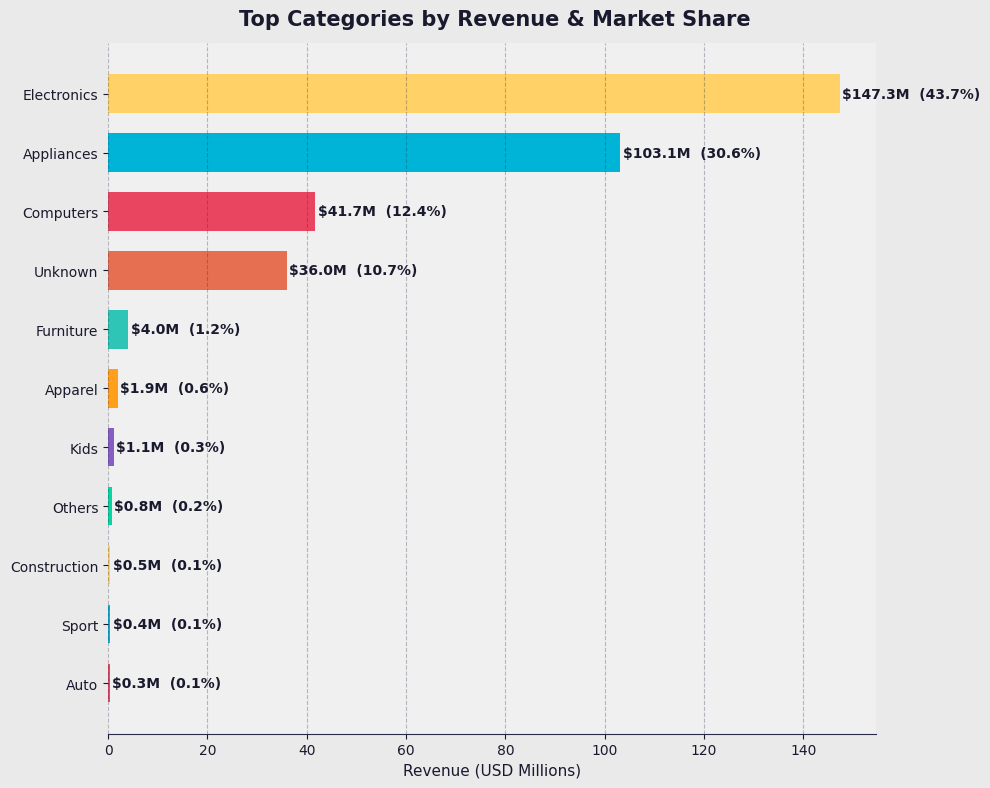

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming rev_cat is already created from your code
total_rev = rev_cat['revenue'].sum()

# 1. Prepare the combined data (Top 10 + Others)
top10 = rev_cat.head(10).copy()
others_rev = rev_cat.iloc[10:]['revenue'].sum()

# Create 'Others' row
others_df = pd.DataFrame([{
    'category_name': 'Others', 
    'revenue': others_rev, 
    'revenue_M': others_rev / 1e6
}])

# Combine and calculate percentages
combined_df = pd.concat([top10, others_df], ignore_index=True)
combined_df['pct'] = (combined_df['revenue'] / total_rev) * 100

# Sort ascending so the largest bar appears at the top of the horizontal chart
combined_df = combined_df.sort_values(by='revenue', ascending=True).reset_index(drop=True)

# 2. Plotting
fig, ax = plt.subplots(figsize=(10, 8), facecolor=DARK_BG)
fig.suptitle('Top Categories by Revenue & Market Share', color=TEXT, fontsize=15, fontweight='bold')

# Create bars
bars = ax.barh(
    combined_df['category_name'].str.title(),
    combined_df['revenue_M'],
    color=PALETTE[:11], # Ensure your PALETTE has enough colors, or use a single color
    edgecolor='none', 
    height=0.65
)

# 3. Add combined annotations ($ + %)
for bar, val, pct in zip(bars, combined_df['revenue_M'], combined_df['pct']):
    ax.text(
        val + 0.5, 
        bar.get_y() + bar.get_height()/2,
        f'${val:.1f}M  ({pct:.1f}%)', # Combines both data points!
        va='center', 
        color=TEXT, 
        fontsize=10,
        fontweight='bold'
    )

# Formatting
ax.set_xlabel('Revenue (USD Millions)', color=SUBTEXT)
ax.set_facecolor(PANEL_BG)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Revenue is highly concentrated. Electronics is the clear leader, generating $147.3M (43.7% of total revenue), followed by Appliances at $103.1M (30.6%). Together, these two categories account for over 74% of total revenue, making the business heavily reliant on their continued performance

#### Are the top revenue-generating categories also leading in order volume and basket size?

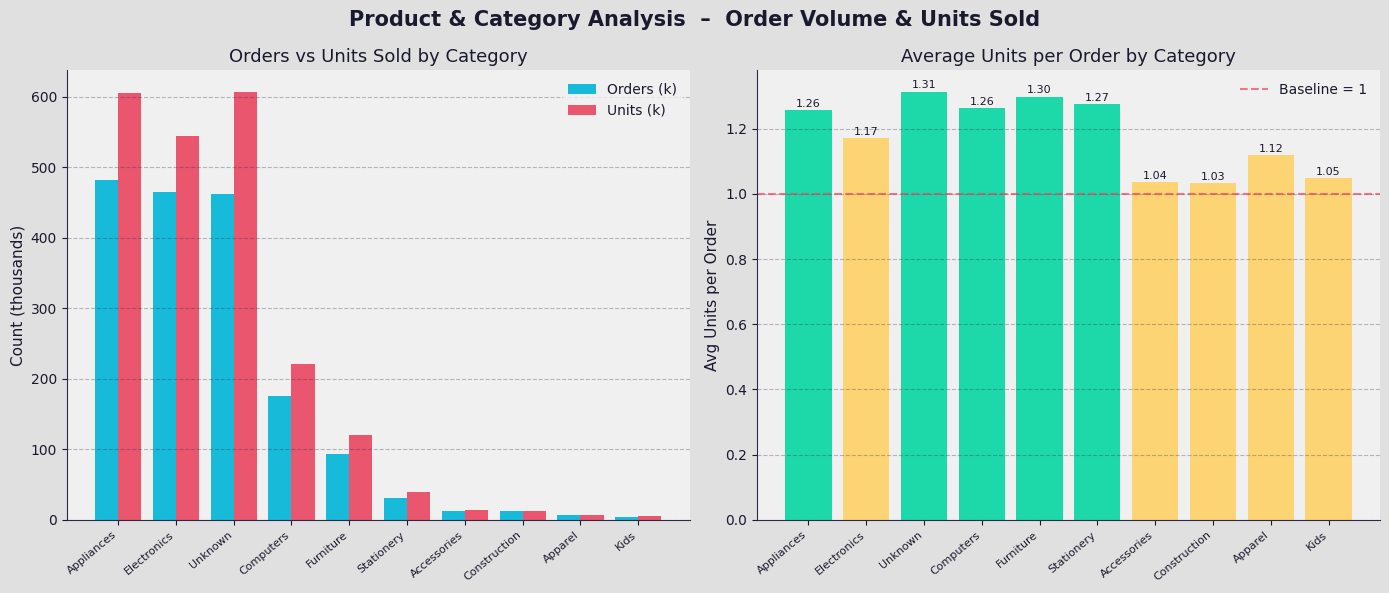

In [8]:
cat_orders = (
    df_final.groupby('category_name')
            .agg(orders=('order_id','nunique'), units=('product_model_id','count'))
            .sort_values('orders', ascending=False)
            .reset_index()
)
cat_orders['units_per_order'] = cat_orders['units'] / cat_orders['orders'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=DARK_BG)
fig.suptitle('Product & Category Analysis  –  Order Volume & Units Sold', color=TEXT, fontsize=15, fontweight='bold')

x = np.arange(len(cat_orders[:10]))
w = 0.4
labels = cat_orders['category_name'].str.title()[:10]

ax1 = axes[0]
b1 = ax1.bar(x - w/2, cat_orders['orders'][:10]/1e3, width=w, color=TEAL, label='Orders (k)', alpha=0.9)
b2 = ax1.bar(x + w/2, cat_orders['units'][:10]/1e3,  width=w, color=ACCENT, label='Units (k)', alpha=0.9)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax1.set_ylabel('Count (thousands)', color=SUBTEXT)
ax1.set_title('Orders vs Units Sold by Category', color=TEXT)
ax1.legend(facecolor=PANEL_BG, labelcolor=TEXT, edgecolor='none')
ax1.grid(axis='y', alpha=0.3); ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
colors2 = [GREEN if v >= 1.25 else GOLD for v in cat_orders['units_per_order'][:10]]
bars2 = ax2.bar(labels, cat_orders['units_per_order'][:10], color=colors2, alpha=0.9)
ax2.axhline(1, color=ACCENT, linestyle='--', alpha=0.7, label='Baseline = 1')
for bar, val in zip(bars2, cat_orders['units_per_order'][:10]):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
             ha='center', fontsize=8, color=TEXT)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
ax2.set_ylabel('Avg Units per Order', color=SUBTEXT)
ax2.set_title('Average Units per Order by Category', color=TEXT)
ax2.legend(facecolor=PANEL_BG, labelcolor=TEXT, edgecolor='none')
ax2.grid(axis='y', alpha=0.3); ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

**Yes**, Appliances and Electronics dominate order volume and units sold. However, there is a distinct difference in basket dynamics. While Appliances sees slightly more total orders (~480k) than Electronics (~460k), Electronics sells more total units. This is reflected in the average units per order: Appliances averages 1.26 units per order, whereas Electronics sits lower at 1.17 units.

### How have sales for products and categories change throughout the year? Are there sudden spikes?

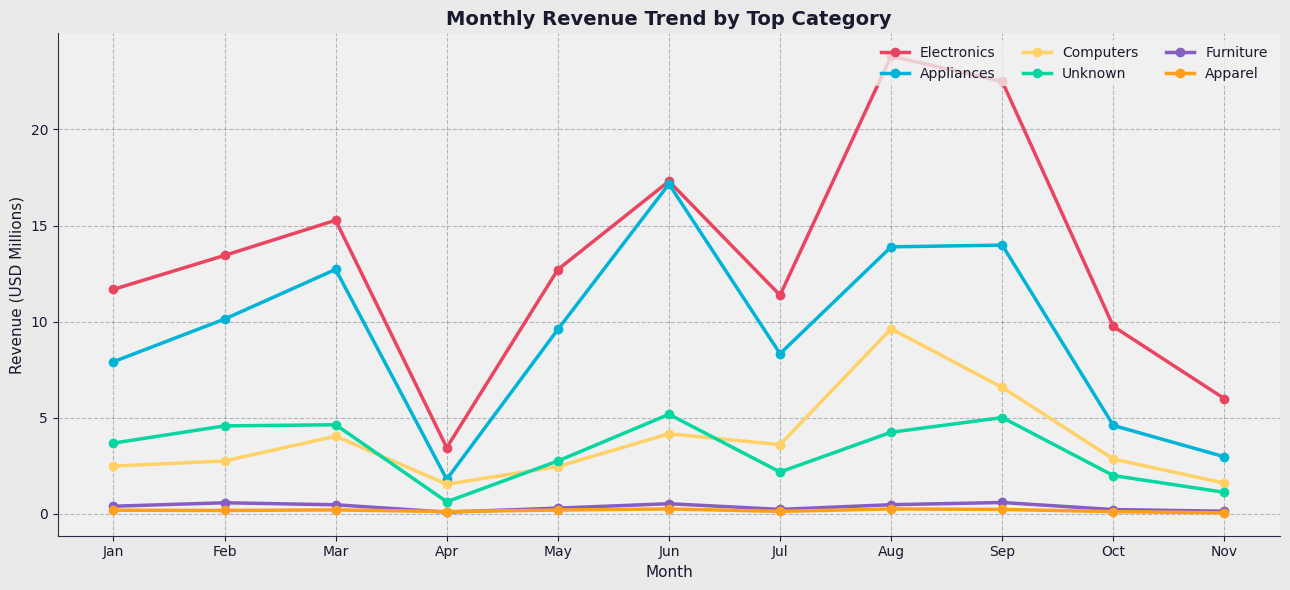

In [13]:
# ── Monthly Revenue by Category – Line Chart ──────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov']
top_cats = rev_cat['category_name'].head(6).tolist()

monthly_cat = (
    df_final[df_final['category_name'].isin(top_cats)]
      .groupby(['Month_Name','category_name'])['price']
      .sum()
      .reset_index()
)
monthly_cat['Month_Name'] = pd.Categorical(monthly_cat['Month_Name'], categories=month_order, ordered=True)
monthly_cat = monthly_cat.sort_values('Month_Name')

fig, ax = plt.subplots(figsize=(13, 6), facecolor=DARK_BG)
for i, cat in enumerate(top_cats):
    sub = monthly_cat[monthly_cat['category_name'] == cat]
    ax.plot(sub['Month_Name'], sub['price']/1e6,
            marker='o', linewidth=2.5, markersize=6,
            color=PALETTE[i], label=cat.title())

ax.set_title('Monthly Revenue Trend by Top Category', color=TEXT, fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)', color=SUBTEXT)
ax.set_xlabel('Month', color=SUBTEXT)
ax.legend(facecolor=PANEL_BG, labelcolor=TEXT, edgecolor='none', ncol=3, loc='upper right')
ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

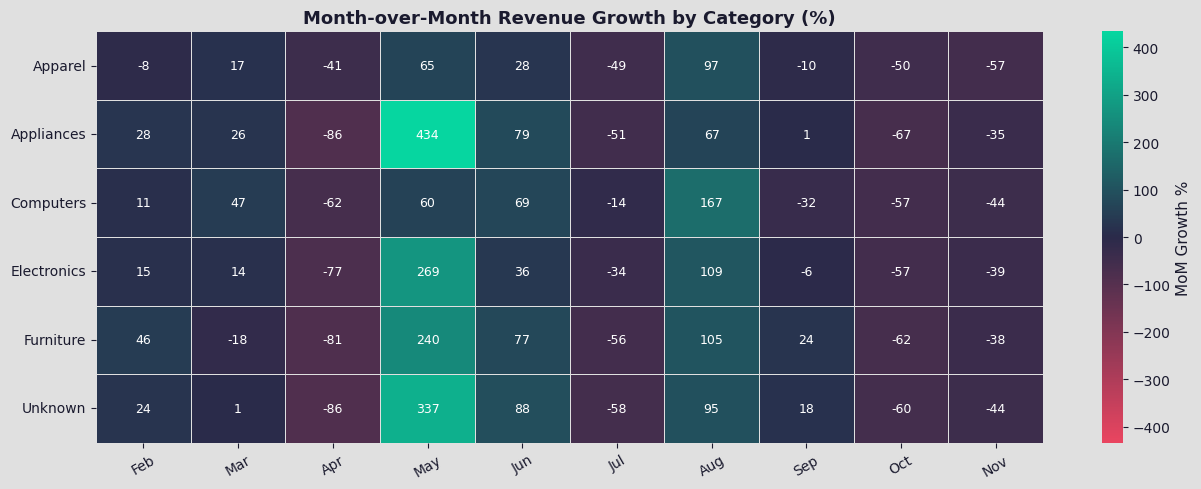

In [ ]:
pivot_rev = monthly_cat.pivot(index='category_name', columns='Month_Name', values='price').fillna(0)
pivot_rev = pivot_rev[month_order]

mom_growth = pivot_rev.pct_change(axis=1) * 100
mom_growth = mom_growth.drop(columns=['Jan'], errors='ignore') 

fig, ax = plt.subplots(figsize=(13, 5), facecolor=DARK_BG)
cmap = LinearSegmentedColormap.from_list('rg', ['#e94560','#2a2a4a','#06d6a0'])
vmax = np.nanmax(np.abs(mom_growth.values))
sns.heatmap(
    mom_growth,
    ax=ax,
    cmap=cmap,
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 9, 'color': 'white'},
    linewidths=0.5,
    linecolor=DARK_BG,
    cbar_kws={'label': 'MoM Growth %'}
)
ax.set_title('Month-over-Month Revenue Growth by Category (%)', color=TEXT, fontsize=13, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_yticklabels([l.get_text().title() for l in ax.get_yticklabels()], color=TEXT, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), color=TEXT, rotation=30)
plt.tight_layout()
plt.savefig('chart_05_mom_growth_heatmap.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

There is volatility in the sales cycle. The data shows a severe revenue drop across all major categories in April (e.g., Appliances fell 86%, Electronics fell 77%), immediately followed by a massive, anomalous surge in May (Appliances jumped 434%, Electronics 269%). A secondary peak occurs in August, followed by a steep decline leading into October and November, which is highly unusual for retail heading into typical Q4 holiday seasons.

Actionable Recommendations

1. Capitalize on High-AOV "Sleeper" Categories. Apparel has a very high AOV ($281.84) but low overall volume. Reallocating some top-of-funnel marketing spend to drive traffic to the Apparel category could yield high returns without needing massive volume.

2. Improve Appliance Upsells since Appliances drive the highest order volume but sit below the store's average AOV, implement aggressive cross-selling strategies at checkout (e.g., warranties, accessories, or complementary items) to push the Appliance AOV above the $239.51 baseline.

3. Prepare for Q4 Drop-offs. The data indicates severe MoM declines in October and November (down 30% to 60% across the board). Implement targeted retention campaigns, early-bird holiday discounts, or re-engagement emails during these months to stabilize cash flow.

---
## 4. Time and Purchase Frequency Analysis

#### How often do recurring customers place new orders?

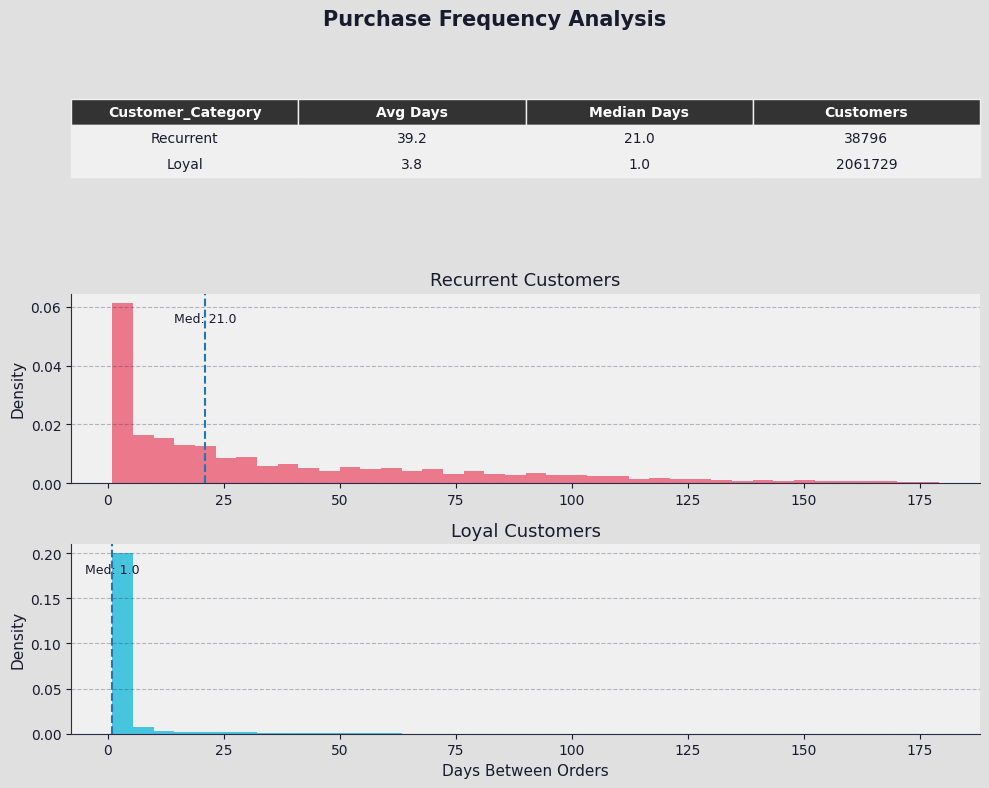

In [ ]:
df_seg = df_final.dropna(subset=['Customer_Category','Avg_days_between_orders']).copy()

df_lr = df_seg[df_seg['Customer_Category'].isin(['Loyal','Recurrent'])]

avg_days_seg = (
    df_lr.groupby('Customer_Category')['Avg_days_between_orders']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={
        'mean': 'Avg Days',
        'median': 'Median Days',
        'count': 'Customers'
    })
)

order = ['Recurrent', 'Loyal']
avg_days_seg['Customer_Category'] = pd.Categorical(
    avg_days_seg['Customer_Category'], categories=order, ordered=True
)
avg_days_seg = avg_days_seg.sort_values('Customer_Category')

fig = plt.figure(figsize=(10, 8), facecolor=DARK_BG)
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1])

fig.suptitle('Purchase Frequency Analysis', color=TEXT, fontsize=15, fontweight='bold')

ax_table = fig.add_subplot(gs[0])
ax_table.axis('off')

table_data = avg_days_seg.round(1).values
col_labels = avg_days_seg.columns

table = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(PANEL_BG)
    if row == 0:
        cell.set_text_props(color='white', weight='bold')
        cell.set_facecolor('#333333')
    else:
        cell.set_text_props(color=TEXT)
        cell.set_facecolor(PANEL_BG)
segments = ['Recurrent', 'Loyal']
colors = {'Recurrent': ACCENT, 'Loyal': TEAL}

for i, seg in enumerate(segments):
    ax = fig.add_subplot(gs[i+1])
    
    subset = df_lr[df_lr['Customer_Category'] == seg]['Avg_days_between_orders']
    subset = subset[subset < 180]  # remove outliers
    
    ax.hist(subset, bins=40, alpha=0.7, color=colors[seg], density=True)

    median_val = subset.median()
    ax.axvline(median_val, linestyle='--', linewidth=1.5)
    ax.text(median_val, ax.get_ylim()[1]*0.85, f'Med: {median_val:.1f}',
            ha='center', color=TEXT, fontsize=9)

    ax.set_title(f'{seg} Customers', color=TEXT)
    ax.set_ylabel('Density', color=SUBTEXT)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

ax.set_xlabel('Days Between Orders', color=SUBTEXT)

plt.tight_layout()
plt.show()

#### What is the overall customer retention rate? How quickly do returning customers make their second purchase?

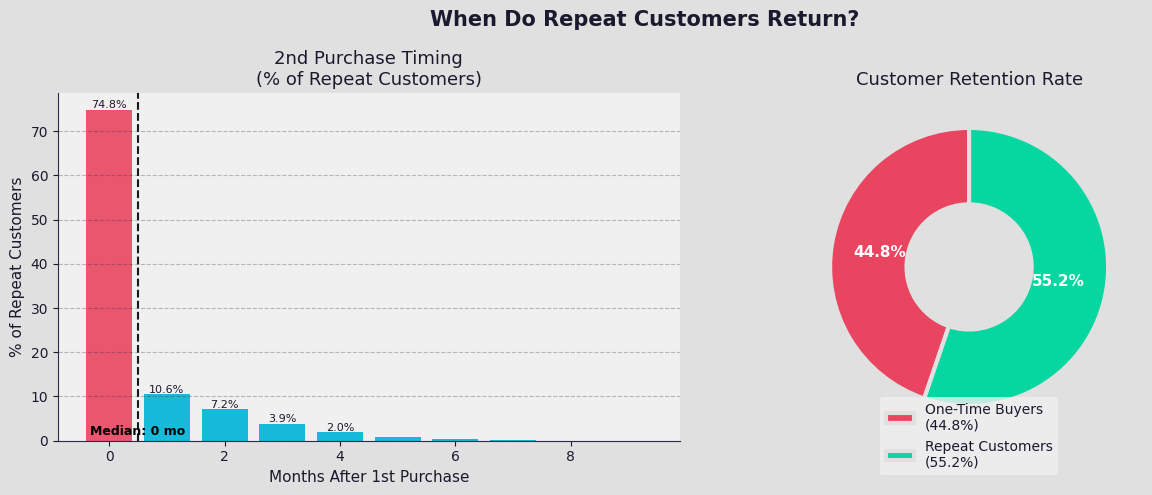

In [ ]:
df_u2 = df_final[df_final['user_id'].notna() & (df_final['user_id'].astype(str)!='nan')].copy()
df_u2['user_id'] = df_u2['user_id'].astype(str)

user_order_dates = (
    df_u2.groupby(['user_id','order_id'])['event_time']
         .min()
         .reset_index()
         .sort_values(['user_id','event_time'])
)
user_order_dates['order_rank'] = user_order_dates.groupby('user_id').cumcount() + 1

first_orders  = user_order_dates[user_order_dates['order_rank']==1][['user_id','event_time']].rename(columns={'event_time':'first_order'})
second_orders = user_order_dates[user_order_dates['order_rank']==2][['user_id','event_time']].rename(columns={'event_time':'second_order'})

repeat_df = first_orders.merge(second_orders, on='user_id')
repeat_df['days_to_2nd'] = (repeat_df['second_order'] - repeat_df['first_order']).dt.days
repeat_df['months_to_2nd'] = (repeat_df['days_to_2nd'] / 30.44).astype(int).clip(0, 12)

month_dist = repeat_df['months_to_2nd'].value_counts().sort_index()
month_dist_pct = month_dist / month_dist.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DARK_BG)
fig.suptitle('When Do Repeat Customers Return?', color=TEXT, fontsize=15, fontweight='bold')

ax1 = axes[0]
median_month = repeat_df['months_to_2nd'].median()

median_line_x = median_month + 0.5

ax1.axvline(median_line_x, color='black', linestyle='--', linewidth=1.5, alpha=0.9)

ax1.text(
    median_line_x,
    ax1.get_ylim()[1]*0.9,
    f'Median: {median_month:.0f} mo',
    color='black',
    ha='center',
    fontsize=9,
    fontweight='bold'
)
bars = ax1.bar(month_dist_pct.index, month_dist_pct.values,
               color=[ACCENT if i==0 else TEAL for i in range(len(month_dist_pct))], alpha=0.9)
ax1.set_title('2nd Purchase Timing\n(% of Repeat Customers)', color=TEXT)
ax1.set_xlabel('Months After 1st Purchase', color=SUBTEXT)
ax1.set_ylabel('% of Repeat Customers', color=SUBTEXT)
for bar, val in zip(bars, month_dist_pct.values):
    if val > 1:
        ax1.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
                 ha='center', fontsize=8, color=TEXT)
ax1.grid(axis='y', alpha=0.3); ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
total_customers  = df_u2['user_id'].nunique()
repeat_customers = repeat_df['user_id'].nunique()
one_time = total_customers - repeat_customers
retention_rate = repeat_customers / total_customers * 100

one_time_pct = 100 - retention_rate
repeat_pct   = retention_rate

cats = [
    f'One-Time Buyers\n({one_time_pct:.1f}%)',
    f'Repeat Customers\n({repeat_pct:.1f}%)'
]
vals  = [one_time, repeat_customers]
cols2 = [ACCENT, GREEN]
wedges, texts, autotexts = ax2.pie(
    vals, labels=None, colors=cols2,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.65, wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=3)
)
for at in autotexts: at.set(color='white', fontsize=11, fontweight='bold')
ax2.set_title(f'Customer Retention Rate', color=TEXT)
ax2.legend(cats, loc='lower center', bbox_to_anchor=(0.5,-0.12), ncol=1,
           labelcolor=TEXT, facecolor=PANEL_BG, edgecolor='none')

plt.tight_layout()
plt.show()

The business demonstrates a remarkably strong retention rate. Over half of the customer base (55.2%) consists of repeat customers, while 44.8% are one-time buyers. 

Conversion to a second purchase happens almost immediately. Nearly three-quarters (74.8%) of all repeat customers make their second purchase within the exact same month (Month 0) as their first purchase.

Actionable Recommendations

1. Trigger Immediate Post-Purchase Marketing, 75% of second purchases and the median return time happen in the same month as the first. Post-purchase marketing, such as a coupon or personalized product recommendations marketing, should be triggered within 24 to 48 hours of the initial purchase.

2. With a confirmed 55.2% of customers returning, the business has a highly engaged audience. Implement or heavily promote a VIP loyalty program to maximize the lifetime value of this substantial group, rewarding them for their rapid and frequent repurchasing behavior.

#### Are there specific months where sales spike or drop significantly?

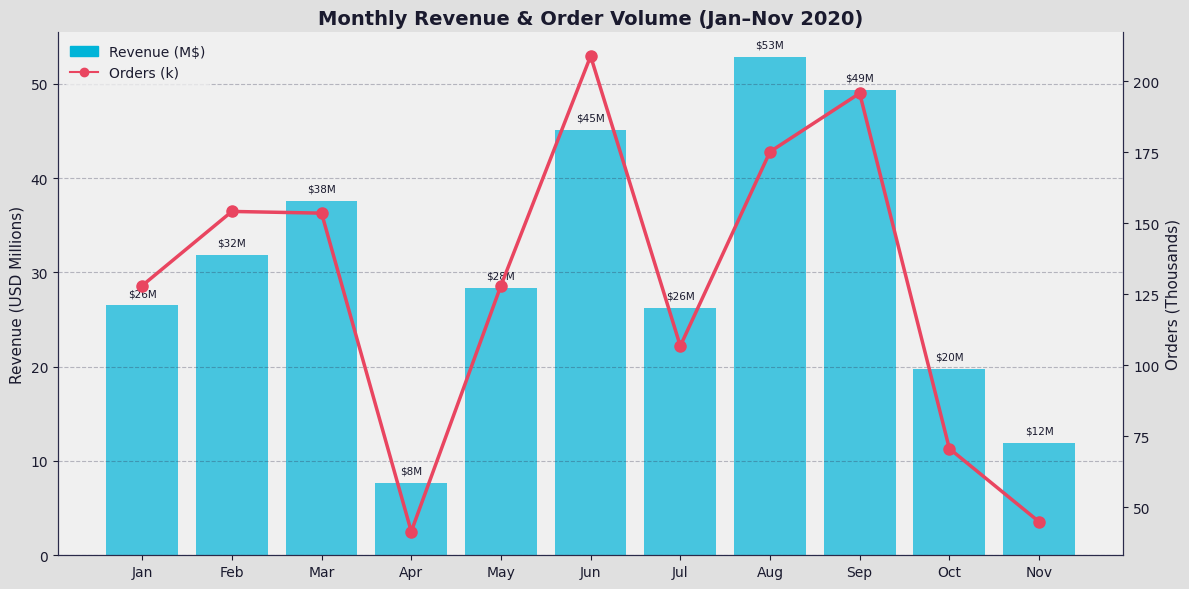

In [ ]:
monthly = (
    df_final.groupby('Month')
            .agg(revenue=('price','sum'), orders=('order_id','nunique'))
            .reset_index()
)
monthly['Month_Name'] = pd.to_datetime(monthly['Month'], format='%m').dt.strftime('%b')
monthly = monthly.sort_values('Month')

fig, ax1 = plt.subplots(figsize=(12, 6), facecolor=DARK_BG)
ax2 = ax1.twinx()

bars = ax1.bar(monthly['Month_Name'], monthly['revenue']/1e6,
               color=TEAL, alpha=0.7, label='Revenue (M$)')
line = ax2.plot(monthly['Month_Name'], monthly['orders']/1e3,
                color=ACCENT, marker='o', linewidth=2.5, markersize=8, label='Orders (k)')

ax1.set_ylabel('Revenue (USD Millions)', color=TEXT)
ax2.set_ylabel('Orders (Thousands)', color=TEXT)
ax1.yaxis.label.set_color(TEXT); ax2.yaxis.label.set_color(TEXT)
ax1.tick_params(axis='y', colors=TEXT); ax2.tick_params(axis='y', colors=TEXT)

ax1.set_title('Monthly Revenue & Order Volume (Jan–Nov 2020)', color=TEXT, fontsize=14, fontweight='bold')
handles = [mpatches.Patch(color=TEAL, label='Revenue (M$)'),
           plt.Line2D([0],[0], color=ACCENT, marker='o', label='Orders (k)')]
ax1.legend(handles=handles, facecolor=PANEL_BG, labelcolor=TEXT, edgecolor='none', loc='upper left')
ax1.grid(axis='y', alpha=0.3); ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

for i, (mn, rev, ord_) in enumerate(zip(monthly['Month_Name'], monthly['revenue']/1e6, monthly['orders']/1e3)):
    ax1.text(i, rev + 1, f'${rev:.0f}M', ha='center', fontsize=7.5, color=TEXT)

plt.tight_layout()
plt.savefig('chart_08_monthly_revenue_orders.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

The data shows extreme monthly volatility throughout 2020. April experienced a severe collapse, with revenue plummeting by roughly 75% to just $8M. This was immediately followed by a massive recovery surge in May continuing to June, where revenue jumped over 250%. The summer months proved to be the strongest period, with order volume peaking in June (over 200k orders) and total revenue peaking in August ($53M). However, there is a sharp and concerning decline heading into October and November.

#### Does the day of the week impact how many orders are placed?

#### At what times during the day are customers most likely to buy?

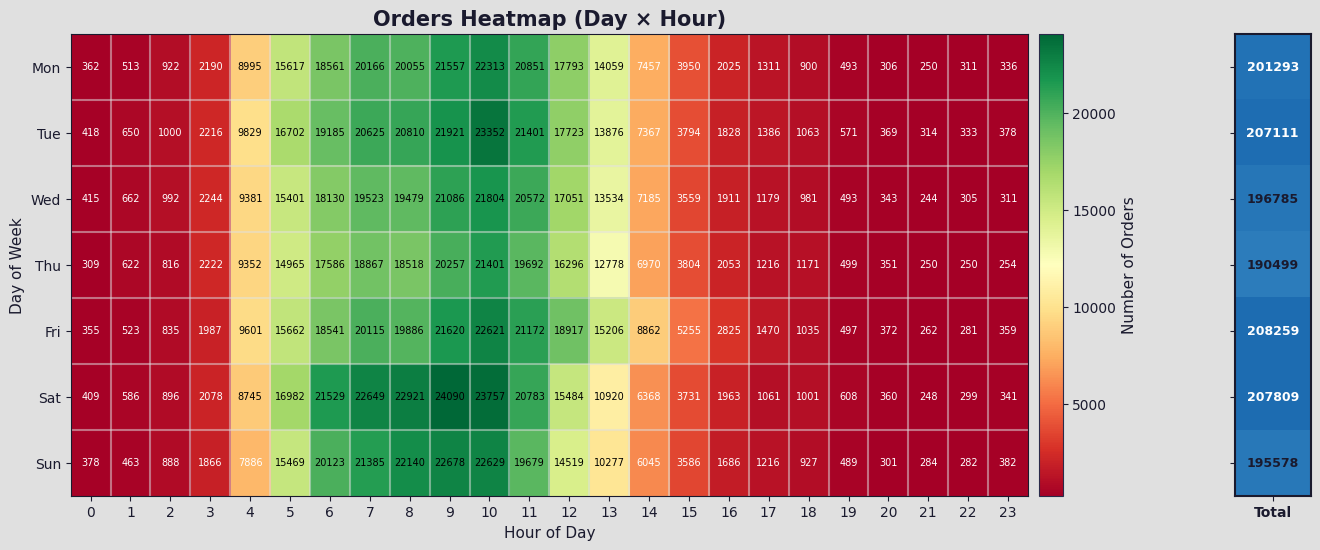

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = (
    df_final.groupby(['Day_Name', 'Hour_Rounded'])['order_id']
            .nunique()
            .reset_index()
            .pivot(index='Day_Name', columns='Hour_Rounded', values='order_id')
            .reindex(day_order)
)
pivot = pivot.fillna(0)

row_totals = pivot.sum(axis=1).values.reshape(-1, 1)

fig = plt.figure(figsize=(16, 6), facecolor=DARK_BG)

gs = gridspec.GridSpec(1, 2, width_ratios=[pivot.shape[1], 1.6],
                       wspace=0.04, figure=fig)

ax_main  = fig.add_subplot(gs[0])
ax_total = fig.add_subplot(gs[1])

im = ax_main.imshow(pivot, aspect='auto', cmap='RdYlGn')

cbar = plt.colorbar(im, ax=ax_main, pad=0.01)
cbar.set_label('Number of Orders', color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)

ax_main.set_xticks(range(len(pivot.columns)))
ax_main.set_xticklabels(pivot.columns, color=SUBTEXT)
ax_main.set_yticks(range(len(pivot.index)))
ax_main.set_yticklabels([d[:3] for d in pivot.index], color=TEXT)
ax_main.set_xlabel('Hour of Day', color=SUBTEXT)
ax_main.set_ylabel('Day of Week', color=SUBTEXT)
ax_main.set_title('Orders Heatmap (Day × Hour)', color=TEXT,
                  fontsize=15, fontweight='bold')

ax_main.set_facecolor(DARK_BG)
for spine in ax_main.spines.values():
    spine.set_edgecolor(SUBTEXT)
ax_main.tick_params(colors=TEXT)

ax_main.set_xticks([x - 0.5 for x in range(1, len(pivot.columns))], minor=True)
ax_main.set_yticks([y - 0.5 for y in range(1, len(pivot.index))],   minor=True)
ax_main.grid(which='minor', color=DARK_BG, linestyle='-', linewidth=1.5)
ax_main.tick_params(which='minor', bottom=False, left=False)

mean_val = pivot.values.mean()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.iloc[i, j]
        if val > 0:
            ax_main.text(j, i, f'{int(val)}',
                         ha='center', va='center', fontsize=7,
                         color='black' if val > mean_val else 'white')

im_tot = ax_total.imshow(row_totals, aspect='auto', cmap='Blues',
                          vmin=0, vmax=row_totals.max() * 1.3)

ax_total.set_xticks([0])
ax_total.set_xticklabels(['Total'], color=TEXT, fontweight='bold')
ax_total.set_yticks(range(len(pivot.index)))
ax_total.set_yticklabels([])         

ax_total.set_facecolor(DARK_BG)
for spine in ax_total.spines.values():
    spine.set_edgecolor(SUBTEXT)
    spine.set_linewidth(1.5)         
ax_total.tick_params(colors=TEXT)

tot_mean = row_totals.mean()
for i, val in enumerate(row_totals[:, 0]):
    ax_total.text(0, i, f'{int(val)}',
                  ha='center', va='center', fontsize=9, fontweight='bold',
                  color='white' if val > tot_mean else TEXT)

plt.suptitle('', y=1)          
plt.tight_layout()
plt.show()

Days
- Order volume is highly consistent across all days
- Thursday is the lowest (~190k orders)
- Friday & Saturday are the highest (~208k orders)
- The difference between highest and lowest days is <10%
- **Demand is stable throughout the week with a slight weekend effect present in purchasing behavior**

Time
- Orders start increasing early at ~6:00 AM
- Peak activity occurs between 10:00 AM – 1:00 PM
- After 1:00 PM, orders drop sharply
- Overnight hours from 11 PM to 6 AM show minimal customer engagement
- **Customer activity is heavily morning and mid-day driven**

Actionable Recommendations
1. Time Marketing Campaigns for the Morning. Vast majority of purchases consistently occur between 7:00 AM and 12:00 PM every single day, all critical email blasts, SMS promotions, and heavy daily ad spend should be deployed early. This helps in capturing the customer right as they enter the intense morning buying window.

2. Reduce Evening Ad Spend. Given the sharp drop in order volume after 1:00 PM and the stark lack of evening activity, time targeting strategies should be implemented to scale down digital ad bidding during the late afternoon and night to conserve the marketing budget.

3. Deploy maximum customer service and technical support personnel during the 10 AM to 2 PM midday rush to efficiently manage the spike in buyer inquiries and keep response times short.

4. Maintain optimal inventory levels and dedicated product support for the Friday through Sunday weekend peak to accommodate shoppers spending extra time evaluating high-ticket electronics.


---
## 5. Basket Analysis

#### How basket sizes drive the revenue?

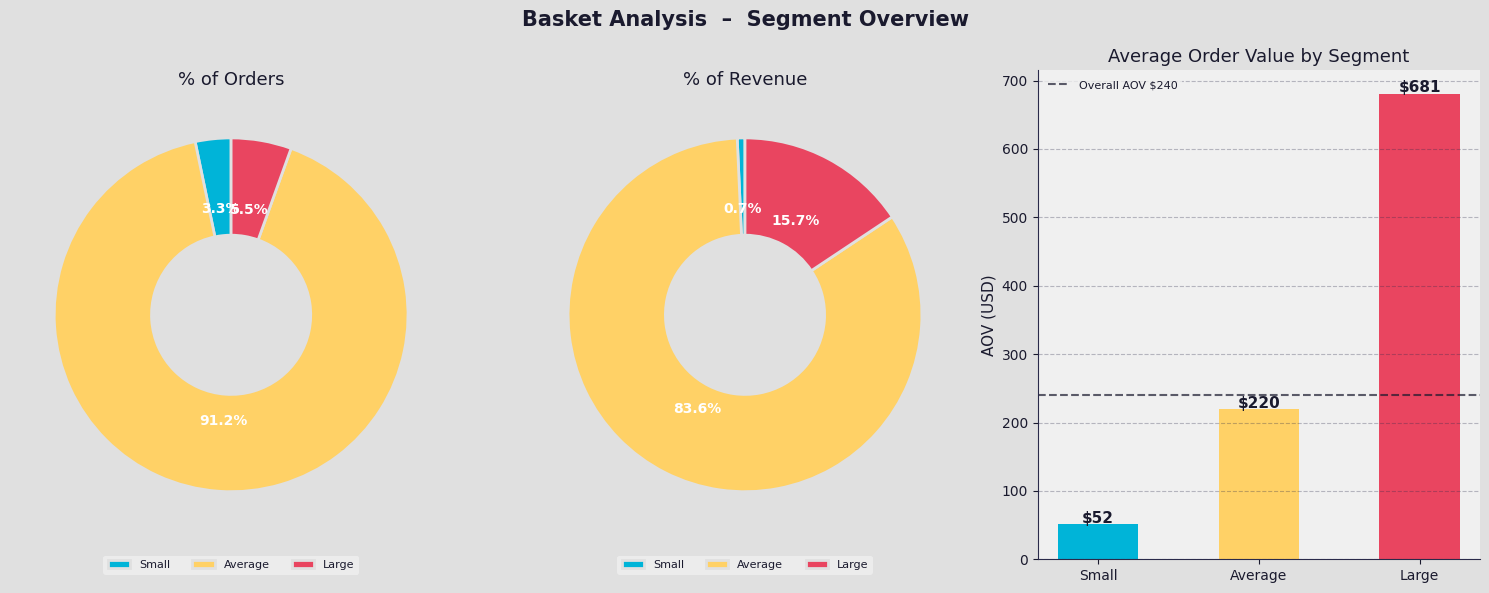

BasketSegment  order_pct  revenue_pct        aov
        Small   3.261912     0.701801  51.530753
      Average  91.230795    83.640534 219.583782
        Large   5.507293    15.657665 680.947740


In [ ]:
df_basket = df_final.dropna(subset=['BasketSegment']).copy()

bs_orders = (
    df_basket.drop_duplicates(['user_id','order_id'])
             .groupby('BasketSegment').size()
             .reset_index(name='order_count')
)

order_vals2 = df_basket.groupby(['user_id','order_id','BasketSegment'])['price'].sum().reset_index()
bs_revenue  = order_vals2.groupby('BasketSegment')['price'].sum().reset_index(name='revenue')
bs_aov      = order_vals2.groupby('BasketSegment')['price'].mean().reset_index(name='aov')

bs_summary = bs_orders.merge(bs_revenue, on='BasketSegment').merge(bs_aov, on='BasketSegment')
bs_summary['order_pct']   = bs_summary['order_count'] / bs_summary['order_count'].sum() * 100
bs_summary['revenue_pct'] = bs_summary['revenue'] / bs_summary['revenue'].sum() * 100
seg_order = ['Small','Average','Large']
bs_summary['BasketSegment'] = pd.Categorical(bs_summary['BasketSegment'], categories=seg_order, ordered=True)
bs_summary = bs_summary.sort_values('BasketSegment')

fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor=DARK_BG)
fig.suptitle('Basket Analysis  –  Segment Overview', color=TEXT, fontsize=15, fontweight='bold')

seg_colors = [TEAL, GOLD, ACCENT]

ax1 = axes[0]
wedges, _, autotexts = ax1.pie(
    bs_summary['order_pct'], labels=None, colors=seg_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2)
)
for at in autotexts: at.set(color='white', fontweight='bold', fontsize=10)
ax1.set_title('% of Orders', color=TEXT)
ax1.legend(seg_order, loc='lower center', bbox_to_anchor=(0.5,-0.1), ncol=3,
           labelcolor=TEXT, facecolor=PANEL_BG, edgecolor='none', fontsize=8)

ax2 = axes[1]
wedges, _, autotexts = ax2.pie(
    bs_summary['revenue_pct'], labels=None, colors=seg_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=DARK_BG, linewidth=2)
)
for at in autotexts: at.set(color='white', fontweight='bold', fontsize=10)
ax2.set_title('% of Revenue', color=TEXT)
ax2.legend(seg_order, loc='lower center', bbox_to_anchor=(0.5,-0.1), ncol=3,
           labelcolor=TEXT, facecolor=PANEL_BG, edgecolor='none', fontsize=8)

ax3 = axes[2]
bars = ax3.bar(bs_summary['BasketSegment'], bs_summary['aov'], color=seg_colors, width=0.5)
for bar, val in zip(bars, bs_summary['aov']):
    ax3.text(bar.get_x()+bar.get_width()/2, val+2, f'${val:.0f}',
             ha='center', color=TEXT, fontweight='bold', fontsize=11)
overall_aov2 = order_vals2['price'].mean()
ax3.axhline(overall_aov2, color=TEXT, linestyle='--', alpha=0.7, label=f'Overall AOV ${overall_aov2:.0f}')
ax3.set_title('Average Order Value by Segment', color=TEXT)
ax3.set_ylabel('AOV (USD)', color=SUBTEXT)
ax3.legend(facecolor=PANEL_BG, labelcolor=TEXT, edgecolor='none', fontsize=8)
ax3.grid(axis='y', alpha=0.3); ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_11_basket_segment_overview.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(bs_summary[['BasketSegment','order_pct','revenue_pct','aov']].to_string(index=False))

The vast majority of business relies on the "Average" basket segment. These middle-tier baskets account for 91.2% of all orders and generate 83.6% of total revenue, with an AOV of $220. However, the "Large" basket segment represents a highly lucrative minority. Despite making up only 5.5% of total orders, Large baskets generate a disproportionate 15.7% of total revenue due to a massive AOV of $681. Conversely, "Small" baskets (AOV of $52) have a negligible impact on the bottom line.

#### When do customers spend the most per order?

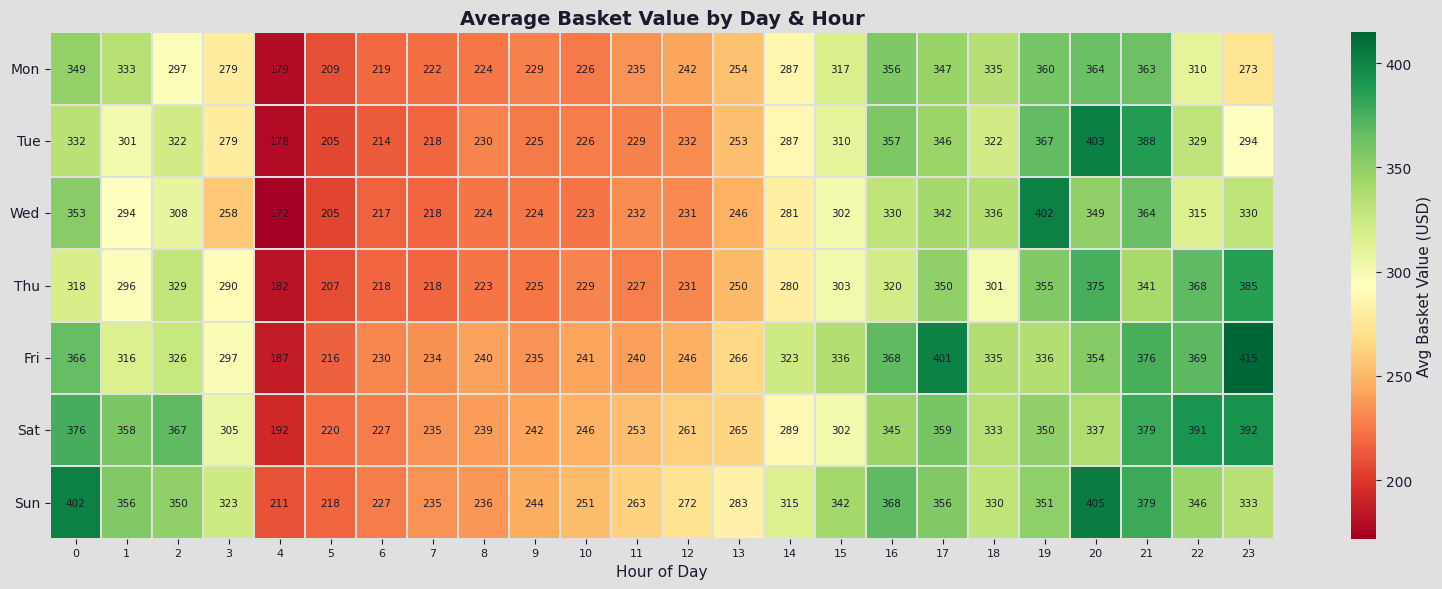

In [ ]:
order_time = (
    df_basket.groupby(['order_id','Day_Name','Hour_Rounded'])['price']
             .sum()
             .reset_index()
)

basket_heatmap = (
    order_time.groupby(['Day_Name','Hour_Rounded'])['price']
              .mean()
              .reset_index()
)

basket_pivot = (
    basket_heatmap
    .pivot(index='Day_Name', columns='Hour_Rounded', values='price')
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 6), facecolor=DARK_BG)

sns.heatmap(
    basket_pivot,
    ax=ax,
    cmap='RdYlGn',  
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7.5, 'color': TEXT},
    linewidths=0.3,
    linecolor=DARK_BG,
    cbar_kws={'label': 'Avg Basket Value (USD)'}
)

ax.set_title('Average Basket Value by Day & Hour', color=TEXT, fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', color=SUBTEXT)
ax.set_ylabel('', color=SUBTEXT)

ax.set_yticklabels([d[:3] for d in day_order], color=TEXT, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), color=TEXT, fontsize=8)

plt.tight_layout()
plt.savefig('chart_12_basket_heatmap_day_hour.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

Basket value moves inversely to order volume—mornings have the most orders but the lowest spend per order, often dropping below $200 between 4:00–6:00 AM.

Average daily spend is tightly clustered between $229–252, showing consistent customer behavior across the week.

Time of day matters more than the day itself: early mornings consistently underperform, while nights and evenings show stronger basket values, likely driven by customer availability.

Actionable Insights

1. Implement a premium loyalty tier and targeted  marketing specifically designed to retain customers purchasing "Large" baskets, as protecting this high-AOV ($681) 5.5% segment is critical to overall profitability. Offering exclusive perks, early access, or dedicated support ensures these high-spenders remain engaged and incentivizes continued premium purchases.

2. Shift marketing focus from day-specific to hour-specific campaigns. The data reveals that while total daily order volume remains relatively flat throughout the entire week, hourly buying behavior fluctuates wildly. Adjusting ad spend and product messaging to match these distinct hourly patterns will generate a much stronger return on investment than running broad, day-long promotions.

---
## 6. Customer Analysis

#### What proportion of the customer base are one-time buyers?

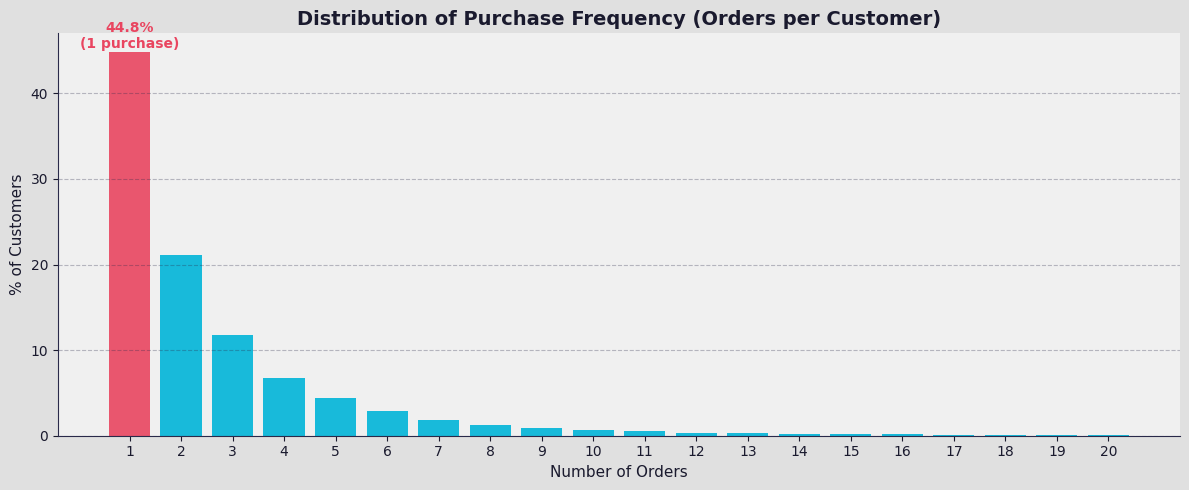

In [ ]:
freq_dist = (
    df_cust.drop_duplicates('user_id')
           .groupby('order_count')
           .size()
           .reset_index(name='users')
)
freq_dist['pct'] = freq_dist['users'] / freq_dist['users'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 5), facecolor=DARK_BG)
top_freq = freq_dist[freq_dist['order_count'] <= 20].copy()
colors_f = [ACCENT if c == 1 else TEAL for c in top_freq['order_count']]
bars = ax.bar(top_freq['order_count'], top_freq['pct'], color=colors_f, alpha=0.9)
ax.set_title('Distribution of Purchase Frequency (Orders per Customer)', color=TEXT, fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders', color=SUBTEXT)
ax.set_ylabel('% of Customers', color=SUBTEXT)

pct_1 = freq_dist[freq_dist['order_count']==1]['pct'].values[0] if 1 in freq_dist['order_count'].values else 0
ax.text(1, pct_1+0.5, f'{pct_1:.1f}%\n(1 purchase)', ha='center', color=ACCENT, fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.savefig('chart_15_purchase_frequency_dist.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

Almost half of the customer base (44.8%) consists of one-time buyers. This means the majority of the base (55.2%) are repeat customers who place two or more orders. However, the volume drops significantly after the second purchase, indicating a steep challenge in getting customers to return for a third, fourth, or fifth time.

#### What are the most popular product categories for different types of buyers?

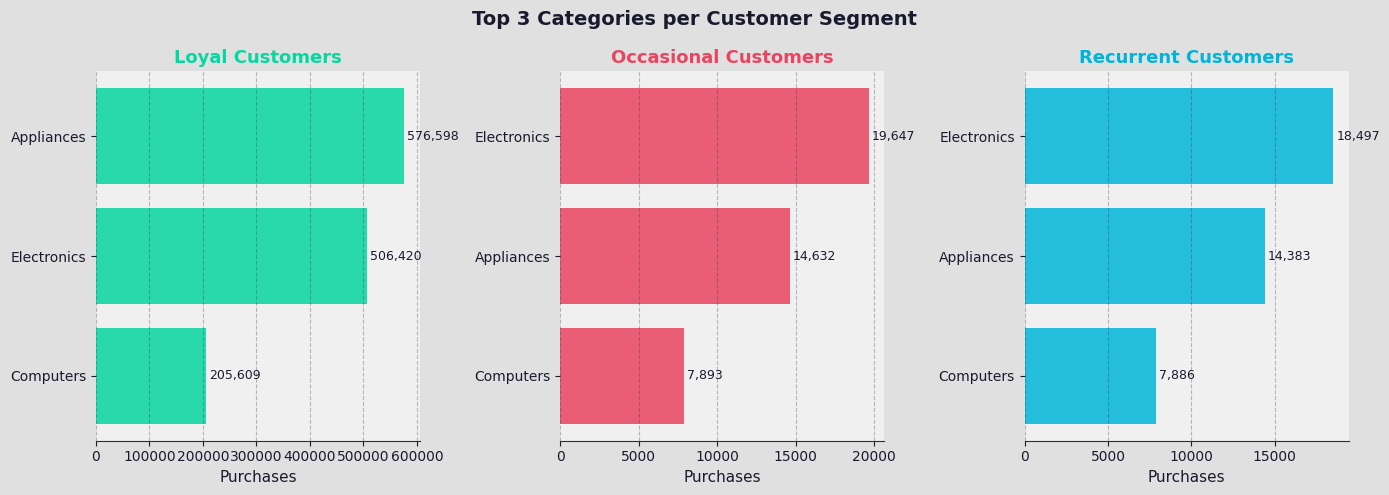

In [ ]:
cat_by_seg = (
    df_cust[df_cust['category_name'] != 'unknown']
      .groupby(['Customer_Category','category_name'])
      .size()
      .reset_index(name='count')
      .sort_values(['Customer_Category','count'], ascending=[True,False])
)
top3_seg = cat_by_seg.groupby('Customer_Category').head(3)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor=DARK_BG)
fig.suptitle('Top 3 Categories per Customer Segment', color=TEXT, fontsize=14, fontweight='bold')

for ax, (seg, grp) in zip(axes, top3_seg.groupby('Customer_Category')):
    col = seg_col_map.get(seg, GOLD)
    bars = ax.barh(grp['category_name'].str.title()[::-1], grp['count'][::-1], color=col, alpha=0.85)
    ax.set_title(f'{seg} Customers', color=col, fontweight='bold')
    ax.set_xlabel('Purchases', color=SUBTEXT)
    for bar, val in zip(bars, grp['count'][::-1]):
        ax.text(val + max(grp['count'])*0.01, bar.get_y()+bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, color=TEXT)
    ax.grid(axis='x', alpha=0.3); ax.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_16_top_categories_by_segment.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

Across all customer segments, the top three purchased categories remain identical: Appliances, Electronics, and Computers.

Note:

To determine which customer belongs to which group, they are segmented directly by the order frequency data shown in the first chart. Customers with exactly one total purchase fall into the "Occasional" segment. Customers with a handful of returning orders (such as 2 or 3 purchases) make up the "Recurrent" segment. Finally, the shoppers with a high frequency of repeated orders (4 or more) are classified as "Loyal."

Actionable Recommendations

1. Design automated email and SMS campaigns aimed directly at the 44.8% of one-time buyers to push them toward a second purchase, heavily featuring the highly popular Electronics category to encourage conversion.

2. Build VIP rewards and exclusive perks specifically around Appliances, since the high-volume Loyal segment clearly favors this category over all others and drives the vast majority of overall sales.

---
## 7. Brand Analysis

### Which brands are generating the most money?

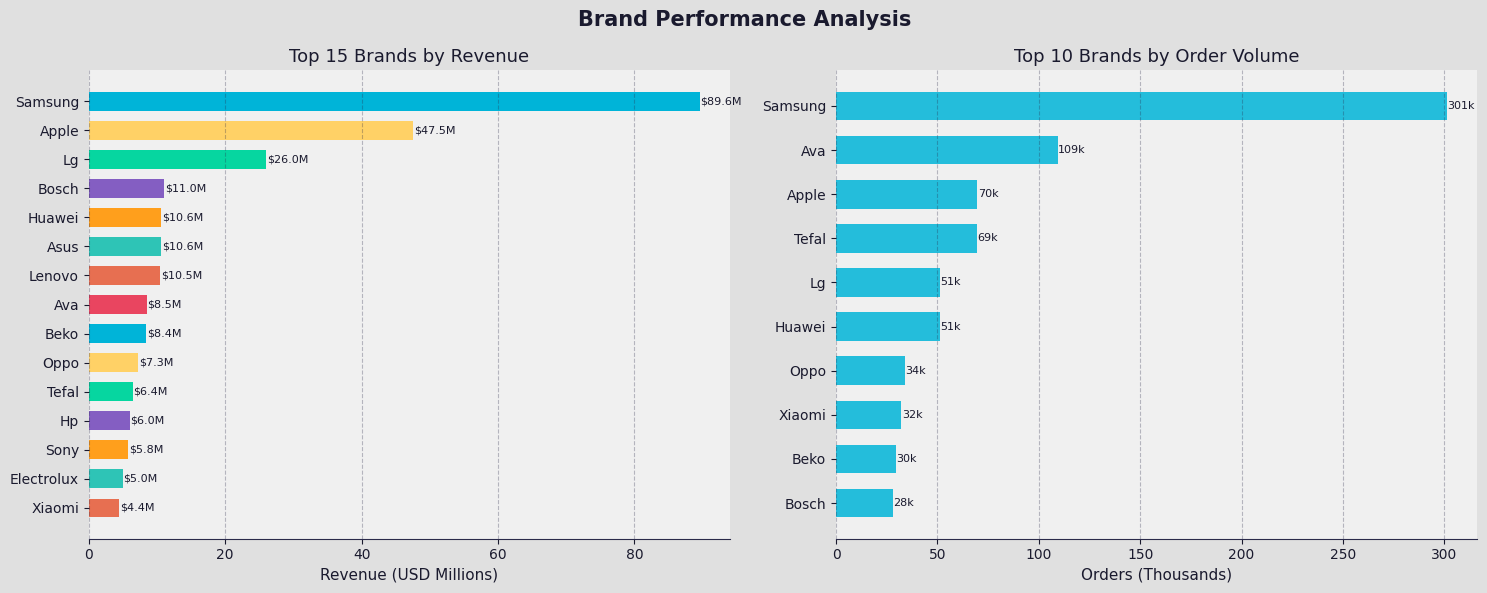

In [ ]:
# ── Top Brands by Revenue & Orders ────────────────────────────────────────────
brand_perf = (
    df_final[df_final['brand_name'] != 'unknown']
      .groupby('brand_name')
      .agg(revenue=('price','sum'), orders=('order_id','nunique'))
      .sort_values('revenue', ascending=False)
      .head(15)
      .reset_index()
)
brand_perf['revenue_M'] = brand_perf['revenue'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=DARK_BG)
fig.suptitle('Brand Performance Analysis', color=TEXT, fontsize=15, fontweight='bold')

ax1 = axes[0]
bars1 = ax1.barh(brand_perf['brand_name'].str.title()[::-1],
                 brand_perf['revenue_M'][::-1],
                 color=PALETTE[:len(brand_perf)][::-1], height=0.65)
for bar, val in zip(bars1, brand_perf['revenue_M'][::-1]):
    ax1.text(val+0.1, bar.get_y()+bar.get_height()/2, f'${val:.1f}M', va='center', fontsize=8, color=TEXT)
ax1.set_xlabel('Revenue (USD Millions)', color=SUBTEXT)
ax1.set_title('Top 15 Brands by Revenue', color=TEXT)
ax1.grid(axis='x', alpha=0.3); ax1.spines[['top','right','left']].set_visible(False)

ax2 = axes[1]
top_brands_orders = brand_perf.sort_values('orders', ascending=False).head(10)
bars2 = ax2.barh(top_brands_orders['brand_name'].str.title()[::-1],
                 top_brands_orders['orders'][::-1]/1e3,
                 color=TEAL, height=0.65, alpha=0.85)
for bar, val in zip(bars2, top_brands_orders['orders'][::-1]/1e3):
    ax2.text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val:.0f}k', va='center', fontsize=8, color=TEXT)
ax2.set_xlabel('Orders (Thousands)', color=SUBTEXT)
ax2.set_title('Top 10 Brands by Order Volume', color=TEXT)
ax2.grid(axis='x', alpha=0.3); ax2.spines[['top','right','left']].set_visible(False)

plt.tight_layout()
# plt.savefig('chart_17_brand_performance.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

Samsung is the biggest contribution in revenue and sales, generating a massive $89.6M in sales, nearly double the second-place brand, Apple, at $47.5M.

Samsung dominates both categories completely, but there are stark differences in basket economics for other brands. For example, Ava is the second most frequently ordered brand overall with 109k orders, but it only ranks eighth in total revenue at just $8.5M. This indicates Ava sells a very high volume of low-cost items. Conversely, Apple generates the second-highest revenue despite having significantly lower order volume than Ava, highlighting its premium pricing and high average order value.

Actionable Recommendations

1. Leverage Samsung's overwhelming dominance in both order volume and total revenue by negotiating better wholesale pricing tiers or securing exclusive marketing funds directly from the manufacturer to improve overall store profit margins.

2. Implement aggressive cross-selling and bundling strategies on high-volume, lower-revenue brands like Ava and Tefal. Since customers are already buying these items frequently, pairing them with high-margin accessories at checkout is a highly effective way to increase their low average order value.

## 8. Risks and Limitaitons

The primary dataset limitation is a severe temporal anomaly. The transactional data was exclusively captured between April and November of 2020. This specific eight-month window aligns perfectly with the global COVID-19 pandemic, which might not reflect usual customer behavior.

The dataset has significant completion issues, as only 8% of the rows are fully intact. 16% of the data had to be completely excluded due to missing critical fields, while the remaining 75% is only partially usable.

The dataset is structured to record individual items rather than complete customer orders. This granular row structure restricts the ability to accurately analyze overall basket values or track multi-item purchasing habits.

## 9. Final Summary
| Analysis Domain        | Market Insight                                                   | Actionable Recommendations                              |
| ---------------------- | ---------------------------------------------------------------- | ------------------------------------------------------- |
| **Product & Category** | Revenue is concentrated in Electronics & Appliances (~74%).      | Diversify by pushing high-AOV categories like apparel.  |
|                        | Appliances drive more orders; Electronics drive more units.      | Use cross-selling to lift appliance order value.        |
|                        | Sales were volatile in 2020 with major dips.                     | Run retention campaigns and early holiday promos.       |
| **Purchase Frequency** | Strong repeat rate (~55%); most second purchases happen quickly. | Trigger post-purchase campaigns within 1–2 days.        |
|                        | Many users repurchase frequently.                                | Launch a VIP/loyalty program to boost LTV.              |
| **Time Analysis**      | Demand is stable; slight weekend lift.                           | Ensure inventory and support for weekend peaks.         |
|                        | Activity peaks late morning to early afternoon.                  | Focus ad spend and staffing during peak hours.          |
|                        | Evenings have fewer orders but higher value.                     | Align campaigns with hourly behavior (volume vs value). |
| **Basket Analysis**    | Large baskets are rare but drive ~16% of revenue.                | Create premium tiers for high spenders.                 |
|                        | Basket value is lower in mornings, higher in evenings.           | Use time-based upselling strategies.                    |
| **Customer Analysis**  | Drop-off occurs after the second purchase.                       | Target first-time buyers to drive second orders.        |
|                        | Loyal buyers favor Appliances.                                   | Build category-specific rewards for loyal users.        |
| **Brand Analysis**     | Samsung dominates; Apple = high value, low volume.               | Negotiate with top brands and leverage co-marketing.    |
|                        | Some brands sell volume but low revenue.                         | Bundle low-cost items with higher-margin products.      |
